In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np


In [2]:
# parquet dosyalarını sıralı şekilde alıyorum
files = sorted(glob.glob("../data/*.parquet"))
print(files)

['../data/yellow_tripdata_2015-01.parquet', '../data/yellow_tripdata_2015-02.parquet', '../data/yellow_tripdata_2015-03.parquet', '../data/yellow_tripdata_2015-04.parquet', '../data/yellow_tripdata_2015-05.parquet', '../data/yellow_tripdata_2015-06.parquet', '../data/yellow_tripdata_2015-07.parquet', '../data/yellow_tripdata_2015-08.parquet', '../data/yellow_tripdata_2015-09.parquet', '../data/yellow_tripdata_2015-10.parquet', '../data/yellow_tripdata_2015-11.parquet', '../data/yellow_tripdata_2015-12.parquet']


In [3]:
# İlk olarak sadece ocak ayı verisini inceliyorum
df_january = pd.read_parquet("../data/yellow_tripdata_2015-01.parquet")
df_january.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,N,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,None,None
1,1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,N,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None
2,1,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,N,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,None,None
3,1,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,N,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,None,None
4,1,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,N,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None


# Veriye genel bakış


In [4]:
# satır ve sütun sayısının kontrol edilmesi
df_january.shape

(12741035, 19)

In [5]:
# sütun isimlerini kontrol ediyorum
df_january.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='str')

In [6]:
# veri tiplerinin kontrol edilmesi
df_january.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int64
trip_distance                   float64
RatecodeID                        int64
store_and_fwd_flag                  str
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge             object
airport_fee                      object
dtype: object

In [7]:
# eksik değerleri kontrol ediyorum
df_january.isnull().sum()

VendorID                        0
tpep_pickup_datetime            0
tpep_dropoff_datetime           0
passenger_count                 0
trip_distance                   0
RatecodeID                      0
store_and_fwd_flag              0
PULocationID                    0
DOLocationID                    0
payment_type                    0
fare_amount                     0
extra                           0
mta_tax                         0
tip_amount                      0
tolls_amount                    0
improvement_surcharge           3
total_amount                    0
congestion_surcharge     12741035
airport_fee              12741035
dtype: int64

In [8]:
# pickup sütununu datetime türüne dönüştürüyorum
df_january["tpep_pickup_datetime"] = pd.to_datetime(
    df_january["tpep_pickup_datetime"],
    errors="coerce")
# Ocak ayı için saatlik trip sayısını hesaplıyorum
january_hourly = (
    df_january.set_index("tpep_pickup_datetime")
    .resample("h")
    .size()
    .reset_index(name="trip_count"))
january_hourly.head()

,tpep_pickup_datetime,trip_count
0,2015-01-01 00:00:00,28312
1,2015-01-01 01:00:00,31707
2,2015-01-01 02:00:00,28068
3,2015-01-01 03:00:00,24288
4,2015-01-01 04:00:00,17081


### Aylık dosyaların eklenmesi


In [9]:
all_data = []

for file in files:

    print("Reading:", file)

    temp_df = pd.read_parquet(
        file,
        columns=[
            "tpep_pickup_datetime",
            "tpep_dropoff_datetime",
            "passenger_count",
            "trip_distance",
            "fare_amount",
            "tip_amount",
            "tolls_amount",
            "total_amount",
            "payment_type",
            "RatecodeID"
        ]
    )

    all_data.append(temp_df)
df = pd.concat(all_data, ignore_index=True)
print(df.shape)

Reading: ../data/yellow_tripdata_2015-01.parquet
Reading: ../data/yellow_tripdata_2015-02.parquet
Reading: ../data/yellow_tripdata_2015-03.parquet
Reading: ../data/yellow_tripdata_2015-04.parquet
Reading: ../data/yellow_tripdata_2015-05.parquet
Reading: ../data/yellow_tripdata_2015-06.parquet
Reading: ../data/yellow_tripdata_2015-07.parquet
Reading: ../data/yellow_tripdata_2015-08.parquet
Reading: ../data/yellow_tripdata_2015-09.parquet
Reading: ../data/yellow_tripdata_2015-10.parquet
Reading: ../data/yellow_tripdata_2015-11.parquet
Reading: ../data/yellow_tripdata_2015-12.parquet
(146039231, 10)


In [10]:
# Sayısal sütunların temel istatistiklerini inceliyorum
df.describe()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount,payment_type,RatecodeID
count,146039231,146039231,1.460392e+08,1.460392e+08,1.460392e+08,1.460392e+08,1.460392e+08,1.460392e+08,1.460392e+08,1.460392e+08
mean,2015-06-26 17:29:12.342669,2015-06-26 17:48:55.793451,1.680858e+00,1.184584e+01,1.293904e+01,1.729140e+00,3.077635e-01,1.609726e+01,1.378856e+00,1.041786e+00
min,2015-01-01 00:00:00,1900-01-01 00:00:00,0.000000e+00,-4.084012e+07,-4.960000e+02,-4.400000e+02,-9.900000e+01,-4.963000e+02,1.000000e+00,1.000000e+00
25%,2015-03-27 13:26:37,2015-03-27 13:42:54.500000,1.000000e+00,1.000000e+00,6.500000e+00,0.000000e+00,0.000000e+00,8.750000e+00,1.000000e+00,1.000000e+00
50%,2015-06-20 18:28:43,2015-06-20 18:43:56,1.000000e+00,1.710000e+00,9.500000e+00,1.160000e+00,0.000000e+00,1.180000e+01,1.000000e+00,1.000000e+00
75%,2015-09-26 23:56:36,2015-09-27 00:12:53,2.000000e+00,3.200000e+00,1.450000e+01,2.300000e+00,0.000000e+00,1.780000e+01,2.000000e+00,1.000000e+00
max,2015-12-31 23:59:59,2253-08-23 07:56:38,9.000000e+00,5.901661e+07,8.259986e+05,3.950589e+06,1.901400e+03,3.950612e+06,5.000000e+00,9.900000e+01
std,NaN,NaN,1.333530e+00,1.093597e+04,1.243789e+02,3.269192e+02,1.646136e+00,3.569951e+02,4.991914e-01,6.533164e-01


In [11]:
# sayısal sütunların min, max, mean ve median değerlerini kontrol ediyorum
numeric_columns = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "tolls_amount",
    "total_amount",
]
for col in numeric_columns:

    print("\nColumn:", col)

    print("Minimum:", df[col].min())

    print("Maximum:", df[col].max())

    print("Mean:", df[col].mean())

    print("Median:", df[col].median())


Column: passenger_count
Minimum: 0
Maximum: 9
Mean: 1.6808580976436394
Median: 1.0

Column: trip_distance
Minimum: -40840124.4
Maximum: 59016609.3
Mean: 11.845839219462885
Median: 1.71

Column: fare_amount
Minimum: -496.0
Maximum: 825998.61
Mean: 12.939035017035936
Median: 9.5

Column: tip_amount
Minimum: -440.0
Maximum: 3950588.8
Mean: 1.7291397760099132
Median: 1.16

Column: tolls_amount
Minimum: -99.0
Maximum: 1901.4
Mean: 0.3077634806910206
Median: 0.0

Column: total_amount
Minimum: -496.3
Maximum: 3950611.6
Mean: 16.09725554950368
Median: 11.8


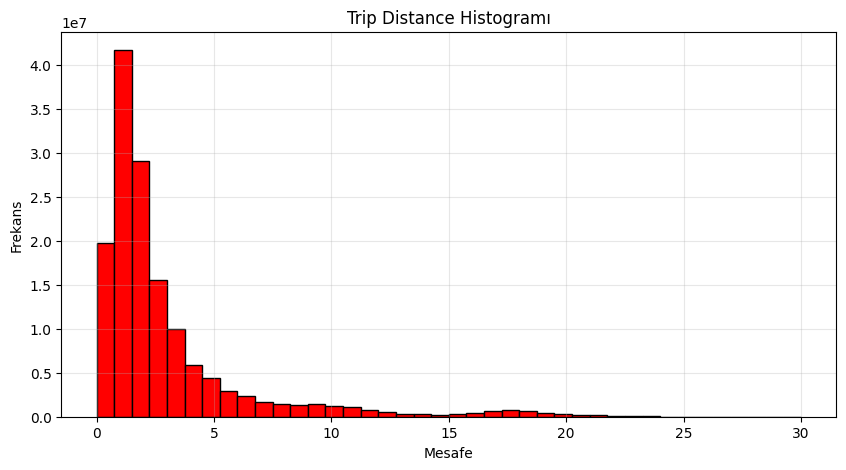

In [12]:

# veri temizliği öncesi histogram 
plt.figure(figsize=(10,5))

plt.hist(
    df["trip_distance"],
    bins=40,
    range=(0, 30),
    edgecolor="black",
    color ="red")
plt.title("Trip Distance Histogramı")
plt.xlabel("Mesafe")
plt.ylabel("Frekans")
plt.grid(alpha=0.3)
plt.show()

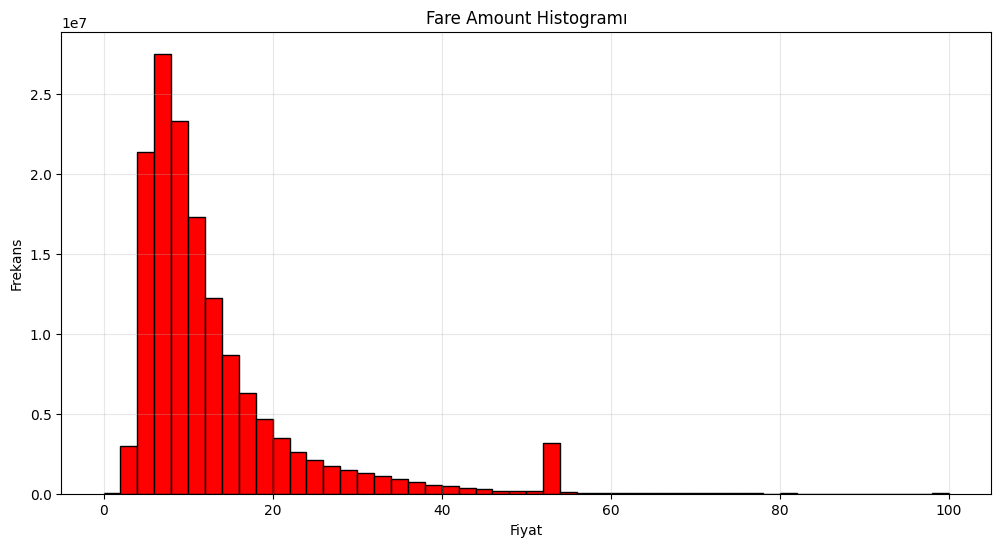

In [13]:
# fare amount temizliği öncesi histogram
plt.figure(figsize=(12,6))

plt.hist(
    df["fare_amount"],
    bins=50,
    range=(0,100),
    edgecolor="black",
    color ="red"
)
plt.title("Fare Amount Histogramı")
plt.xlabel("Fiyat")
plt.ylabel("Frekans")
plt.grid(alpha=0.3)
plt.show()

In [14]:
# # negatif ve mantıksız değerleri kontrol ettikten sonra outlier temizleme işlemlerinde IQR yöntemini kullandım
print("Passenger count <= 0:", (df["passenger_count"] <= 0).sum())

print("Trip distance <= 0:", (df["trip_distance"] <= 0).sum())

print("Fare amount <= 0:", (df["fare_amount"] <= 0).sum())

print("Negative tip amounts:", (df["tip_amount"] < 0).sum())



Passenger count <= 0: 40683
Trip distance <= 0: 876729
Fare amount <= 0: 87046
Negative tip amounts: 1008


# veride çok fazla aykırı değer bulunduğu için outlier temizleme işleminde IQR yöntemini kullanıyorum

In [15]:
# IQR için kontrol edilecek sayısal sütunlar: tolls amaount ve passenger count çıkarıldı. 
# tolss amaountta lower ve upper 0 gözüktü datasette çoğu yolculuk toll road kullanmadığı için kaldırdım. 
# passenger count'u ise lower boundda -4 değeri ve upper bounnda 7 değeri çıktı ben zaten bunu <= 5 olarak sınırlandırmıştım.
iqr_columns = [
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
]
iqr_bounds = {}
for col in iqr_columns:
    # Q1 ve Q3 değerlerini hesaplıyorum
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
   
    IQR = Q3 - Q1

    # daha esnek sınırlar için 1.5 yerine 5* kullandım
    lower_bound = Q1 - 5 * IQR
    upper_bound = Q3 + 5 * IQR

    # alt ve üst sınırları kaydedilmesi
    iqr_bounds[col] = (
        lower_bound,
        upper_bound)
    print(col)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print()

trip_distance
Lower bound: -10.0
Upper bound: 14.2

fare_amount
Lower bound: -33.5
Upper bound: 54.5

tip_amount
Lower bound: -11.5
Upper bound: 13.8

total_amount
Lower bound: -36.5
Upper bound: 63.05



In [16]:
# IQR sınırlarına göre temizleme koşullarını oluşturuyorum
condition = (
    (df["passenger_count"] > 0) &
    (df["passenger_count"] <= 5) &
    (df["trip_distance"] > 0) &
    (df["fare_amount"] > 0) &
    (df["tip_amount"] >= 0) &
    (df["total_amount"] > 0)
)

for col in iqr_columns:

    lower_bound, upper_bound = iqr_bounds[col]

    condition = condition & (
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    )

df_clean = df.loc[condition].copy()

print("Before cleaning:", df.shape)
print("After cleaning:", df_clean.shape)

Before cleaning: (146039231, 10)
After cleaning: (135538755, 10)


In [17]:
# # pickup datetime sütununu datetime formatına dönüştürülmesi
df_clean["tpep_pickup_datetime"] = pd.to_datetime(
    df_clean["tpep_pickup_datetime"],
    errors="coerce" )
# dropoff datetime sütununu datetime formatına dönüştürüyorum
df_clean["tpep_dropoff_datetime"] = pd.to_datetime(
    df_clean["tpep_dropoff_datetime"],
    errors="coerce")
# boş datetime değerlerini kaldırıyorum
df_clean = df_clean.dropna(
    subset=[
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime"
    ])
# sadece 2015 yılı içindeki verileri tutuyorum
df_clean = df_clean[
    (df_clean["tpep_pickup_datetime"] >= "2015-01-01") &
    (df_clean["tpep_pickup_datetime"] < "2016-01-01") ]
print("Cleaned dataset shape:", df_clean.shape)

Cleaned dataset shape: (135538755, 10)


In [18]:
df_clean.describe()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount,payment_type,RatecodeID
count,135538755,135538755,1.355388e+08,1.355388e+08,1.355388e+08,1.355388e+08,1.355388e+08,1.355388e+08,1.355388e+08,1.355388e+08
mean,2015-06-26 12:48:07.213985,2015-06-26 13:08:02.332855,1.523146e+00,2.513792e+00,1.154340e+01,1.515139e+00,1.741112e-01,1.435502e+01,1.377099e+00,1.003925e+00
min,2015-01-01 00:00:00,1973-05-09 09:17:59,1.000000e+00,1.000000e-02,1.000000e-02,0.000000e+00,-5.540000e+00,1.000000e-02,1.000000e+00,1.000000e+00
25%,2015-03-27 05:52:07,2015-03-27 06:04:41.500000,1.000000e+00,1.000000e+00,6.500000e+00,0.000000e+00,0.000000e+00,8.320000e+00,1.000000e+00,1.000000e+00
50%,2015-06-20 11:58:21,2015-06-20 12:11:42,1.000000e+00,1.700000e+00,9.500000e+00,1.150000e+00,0.000000e+00,1.176000e+01,1.000000e+00,1.000000e+00
75%,2015-09-26 22:50:07,2015-09-26 23:06:07,2.000000e+00,3.000000e+00,1.400000e+01,2.250000e+00,0.000000e+00,1.700000e+01,2.000000e+00,1.000000e+00
max,2015-12-31 23:59:59,2253-08-23 07:56:38,5.000000e+00,1.420000e+01,5.450000e+01,1.380000e+01,6.000000e+01,6.305000e+01,5.000000e+00,9.900000e+01
std,NaN,NaN,1.067810e+00,2.389599e+00,7.318186e+00,1.810862e+00,9.753377e-01,8.940231e+00,4.954371e-01,3.569590e-01


In [19]:
df_clean

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount,payment_type,RatecodeID
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.00,5.7,1.40,0.0,8.40,1,1
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.90,6.0,0.00,0.0,7.30,3,1
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.50,13.2,2.90,0.0,17.40,1,1
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.10,8.2,2.37,0.0,11.87,1,1
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.00,6.0,0.00,0.0,7.30,3,1
...,...,...,...,...,...,...,...,...,...,...
146039226,2015-12-31 23:35:31,2015-12-31 23:53:32,1,4.50,16.5,10.00,0.0,27.80,1,1
146039227,2015-12-31 23:57:59,2016-01-01 00:01:23,2,0.50,4.5,1.15,0.0,6.95,1,1
146039228,2015-12-31 23:14:15,2015-12-31 23:29:44,1,2.69,12.0,0.00,0.0,13.30,2,1
146039229,2015-12-31 23:54:50,2016-01-01 00:03:52,1,1.35,8.0,1.86,0.0,11.16,1,1


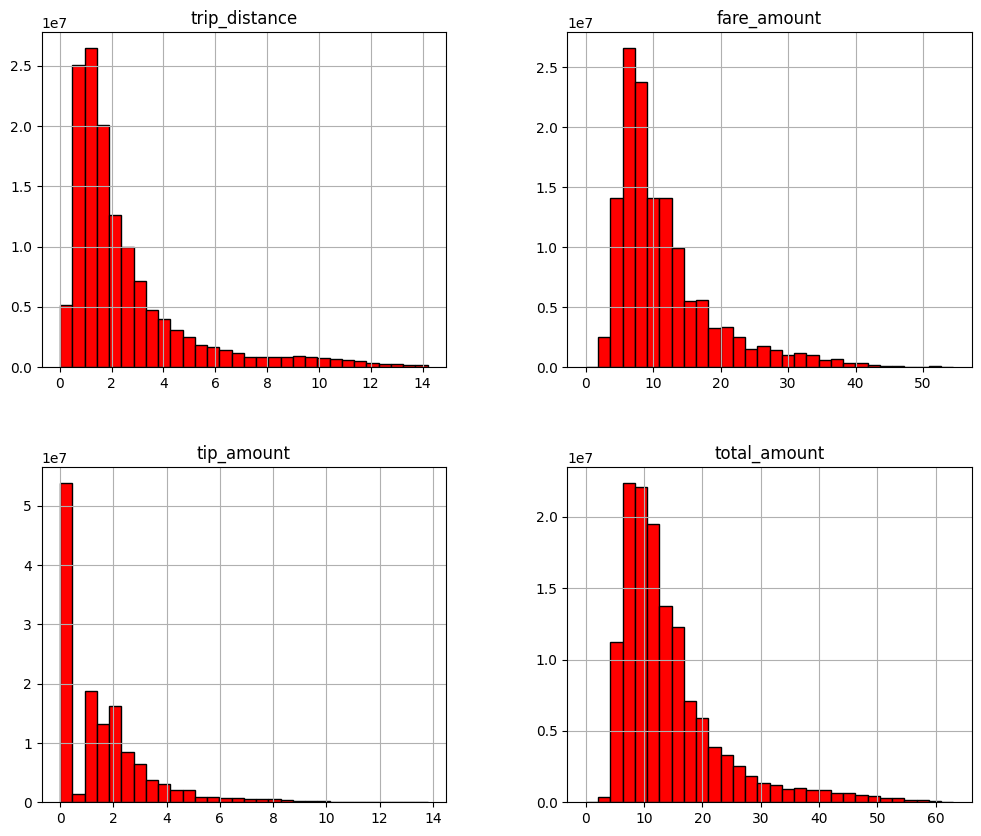

In [20]:
df_clean[
    [
        "trip_distance",
        "fare_amount",
        "tip_amount",
        "total_amount"
    ]
].hist(
    figsize=(12,10),
    bins=30,
    edgecolor="black",
    color="red")
plt.show()

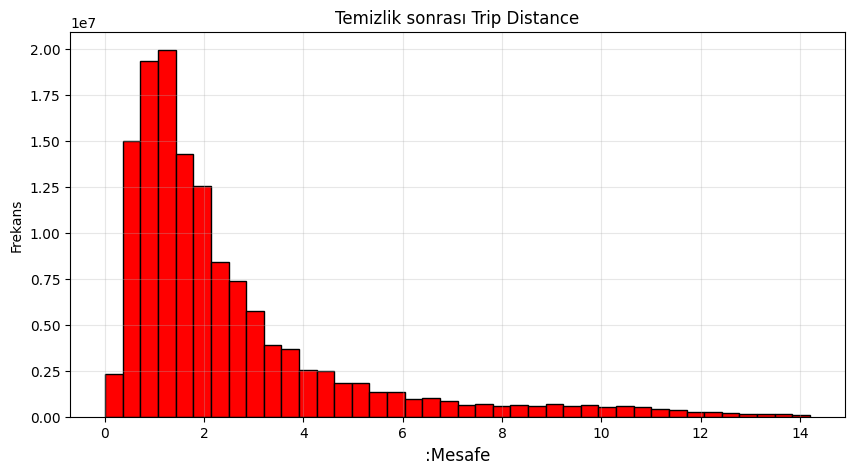

In [21]:
# IQR temizliği sonrası sonrası histogram
plt.figure(figsize=(10,5))

plt.hist(
    df_clean["trip_distance"],
    bins=40,
    edgecolor="black",
    color="red")
plt.xlabel(
    ":Mesafe",
    fontsize=12)
plt.grid(alpha=0.3)
plt.ylabel(
    "Frekans",
    fontsize=10)
plt.title("Temizlik sonrası Trip Distance")
plt.show()

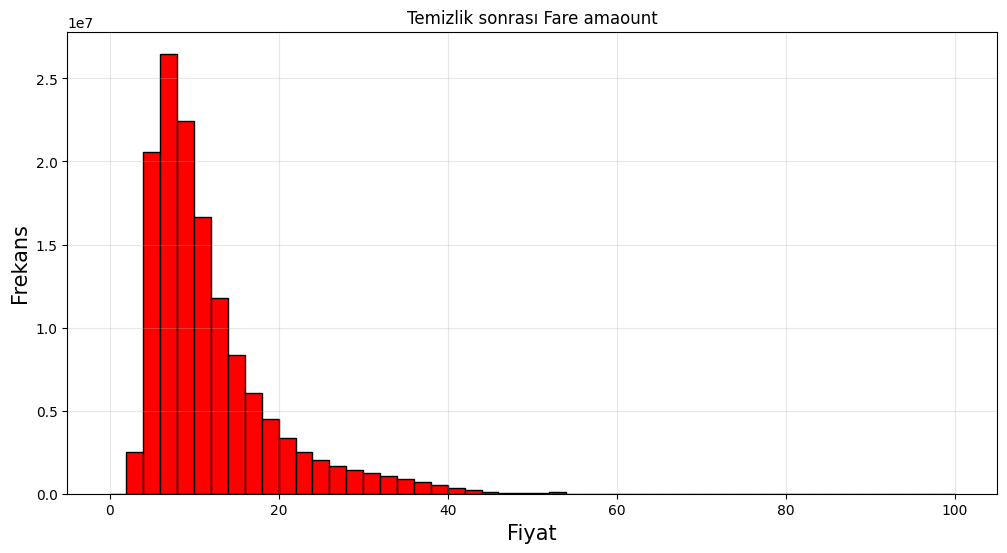

In [22]:
# fare amount histogram
plt.figure(figsize=(12,6))

plt.hist(
    df_clean["fare_amount"],
    bins=50,
    range=(0,100),
    edgecolor="black",
    color="red")

plt.title("Temizlik sonrası Fare amaount")
plt.xlabel(
    "Fiyat",
    fontsize=15)
plt.ylabel(
    "Frekans",
    fontsize=15)
plt.grid(alpha=0.3)
plt.show()

# Z-Score
## Bu yöntem, değerlerin ortalamadan kaç standart sapma uzak olduğunu gösterir.
## z = (x - μ) / σ
## x= veri değeri, μ = ortalama, σ = standart sapma

In [23]:
#alttaki kütüphane formülü otomatik hesaplıyor.
from scipy.stats import zscore

# Z-score hesaplanırken yeni sütunlar eklendiği için ana temiz veri setini bozmamak adına df_clean verisinin kopyasını oluşturdum
df_zscore = df_clean.copy()

# Z-score hesaplanacak sütunlar
zscore_columns = [
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount"
]
# Her sütun için z-score değerlerini hesaplanması
for col in zscore_columns:
    df_zscore[col + "_zscore"] = zscore(
        df_zscore[col]
)

# |z-score| > 4 olan değerleri aykırı değer olarak kontrol ediyorum
for col in zscore_columns:
    outlier_count = (
        df_zscore[col + "_zscore"].abs() > 4
    ).sum()
    print(col, "Z-score outliers:", outlier_count)

trip_distance Z-score outliers: 990953
fare_amount Z-score outliers: 656894
tip_amount Z-score outliers: 1071645
total_amount Z-score outliers: 1075069


###  -- Z-score yöntemi IQR yöntemine göre daha fazla outlier tespit etti. Bu yöntem IQR yöntemine göre daha fazla aykırı değer buldu.

## Yıl boyu saatlik trip sayısı

In [24]:
#  saatlik trip sayısını hesaplanması
hourly_data = (
    df_clean[["tpep_pickup_datetime"]]
    .copy()
)
hourly_data["pickup_hour"] = hourly_data["tpep_pickup_datetime"].dt.floor("h")
hourly_data = (
    hourly_data
    .groupby("pickup_hour")
    .size()
    .reset_index(name="trip_count"))
hourly_data = hourly_data.rename(
    columns={"pickup_hour": "tpep_pickup_datetime"})
hourly_data.head()

,tpep_pickup_datetime,trip_count
0,2015-01-01 00:00:00,26863
1,2015-01-01 01:00:00,30023
2,2015-01-01 02:00:00,26474
3,2015-01-01 03:00:00,22833
4,2015-01-01 04:00:00,15841


In [25]:
hourly_data.describe()

,tpep_pickup_datetime,trip_count
count,8760,8760.000000
mean,2015-07-02 11:30:00,15472.460616
min,2015-01-01 00:00:00,13.000000
25%,2015-04-02 05:45:00,10352.000000
50%,2015-07-02 11:30:00,17121.500000
75%,2015-10-01 17:15:00,20310.250000
max,2015-12-31 23:00:00,43452.000000
std,NaN,7020.842424


In [26]:
hourly_data.shape

(8760, 2)

In [27]:
# saatlik trip count verisini csv olarak kaydediyorum
hourly_data.to_csv(
    "../outputs/hourly_trip_counts_2015.csv",
    index=False)
print("CSV dosyası kaydedildi")

CSV dosyası kaydedildi


# Feature Engineering


In [ ]:
# -- saat ve takvim bilgisi --
hourly_data["pickup_hour"]      = hourly_data["tpep_pickup_datetime"].dt.hour
hourly_data["pickup_dayofweek"] = hourly_data["tpep_pickup_datetime"].dt.dayofweek
hourly_data["pickup_month"]     = hourly_data["tpep_pickup_datetime"].dt.month
hourly_data["pickup_day"]       = hourly_data["tpep_pickup_datetime"].dt.day

In [29]:
# -- hafta sonu bilgisi --
# # Cumartesi(5) ve Pazar(6) ise 1, değilse 0
hourly_data["is_weekend"] = (
    hourly_data["pickup_dayofweek"]
    .isin([5, 6])
    .astype(int))

In [30]:
# -- Rush hour bilgisi -
# Sabah 07-09 ve akşam 16-19 arası yoğun trafik saatleri
hourly_data["is_rush_hour"] = (
    hourly_data["pickup_hour"]
    .isin([7, 8, 9, 16, 17, 18, 19])
    .astype(int))

In [31]:
hourly_data.head()

,tpep_pickup_datetime,trip_count,pickup_hour,pickup_dayofweek,pickup_month,pickup_day,is_weekend,is_rush_hour
0,2015-01-01 00:00:00,26863,0,3,1,1,0,0
1,2015-01-01 01:00:00,30023,1,3,1,1,0,0
2,2015-01-01 02:00:00,26474,2,3,1,1,0,0
3,2015-01-01 03:00:00,22833,3,3,1,1,0,0
4,2015-01-01 04:00:00,15841,4,3,1,1,0,0


## --Saatlere göre ortalama trip sayısı--

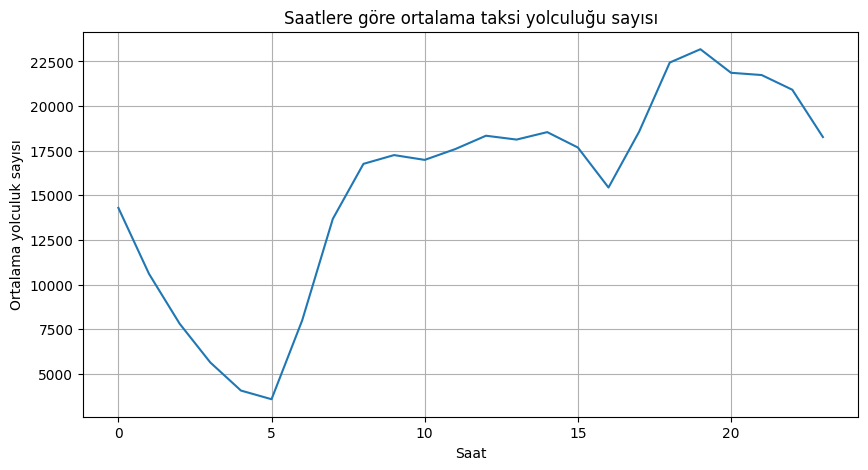

In [32]:
plt.figure(figsize=(10,5))
hourly_data.groupby("pickup_hour")["trip_count"].mean().plot()
plt.title("Saatlere göre ortalama taksi yolculuğu sayısı")
plt.xlabel("Saat")
plt.ylabel("Ortalama yolculuk sayısı")
plt.grid(True)
plt.show()

### taksi talebinin sabah erken saatlerde düşük, en yüksek talep yaklaşık 18:00–20:00 saatleri arasında gerçekleşmektedir

## --Haftanın günlerine göre ortalama trip sayısı--

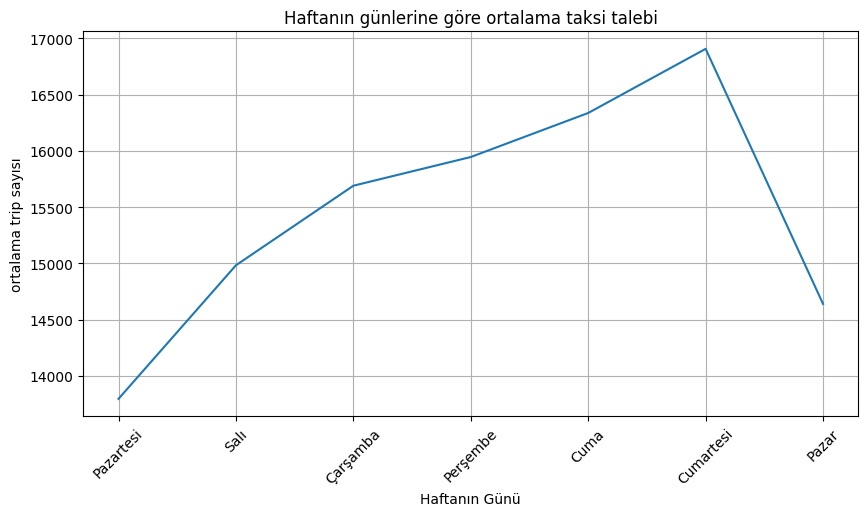

In [33]:
günler = [
    "Pazartesi",
    "Salı",
    "Çarşamba",
    "Perşembe",
    "Cuma",
    "Cumartesi",
    "Pazar" ]
hourly_data.groupby("pickup_dayofweek")["trip_count"].mean().plot(figsize=(10,5))
plt.title("Haftanın günlerine göre ortalama taksi talebi")
plt.xlabel("Haftanın Günü")
plt.ylabel("ortalama trip sayısı")
plt.xticks(range(7), günler, rotation=45)
plt.grid(True)
plt.show()

### grafikte hafta sonuna doğru talebin arttığı görülmekedir.Özellikle cumartesi günü en yüksek ortalama trip sayısına sahip.